# Universal Grammar Generative Model

## Setup stage

In [1]:
INSTALL = false

if INSTALL
    using Pkg
    Pkg.add("StatsPlots"); using StatsPlots
    Pkg.activate("psyc261")
    Pkg.add(["JLD2", "Distributions", "ProgressMeter", "Parameters", 
            "Random", "Gen", "Plots", "PyCall", "Conda", "JSON3"])
end

In [2]:
include("../src/ug_model.jl")
using .UGmodel

In [3]:
using Pkg
Pkg.activate("psyc261")
using JLD2
using Distributions
using ProgressMeter
using Parameters
using Random
using StatsPlots
using Gen, Plots
using PyCall
np = pyimport("numpy")

  Activating project at `~/Algorithms-of-the-Mind/aom/notebooks/psyc261`


PyObject <module 'numpy' from '/home/psyc2610_jdp69/.local/lib/python3.11/site-packages/numpy/__init__.py'>

## Generative Model

To start off, we extract the vocabulary from an external file and parse them into the grammatical categories that we established. In this case, they are nouns, transitive and intransitive verbs, adjectives and a Wh- word (what). After that, we create the fixed vocabulary used for inference.

In [4]:
const NOUNS = UGmodel.LEXICON.nouns
const VERBS_TRANS = UGmodel.LEXICON.verbs_trans
const VERBS_INTR = UGmodel.LEXICON.verbs_intr
const ADJECTIVES = UGmodel.LEXICON.adjectives
const WH_WORD = UGmodel.LEXICON.wh_word
const COMPL = UGmodel.LEXICON.complementizer

"that"

In [5]:
# Creating fixed size vocabulary
const VOCAB = unique(vcat(["PAD", WH_WORD, COMPL], NOUNS, VERBS_TRANS, VERBS_INTR, ADJECTIVES))
const VOCAB_SIZE = length(VOCAB)
const WORD_TO_IDX = Dict(w => i for (i,w) in enumerate(VOCAB))
const MAX_SENT_LEN = 12

12

In [6]:
const NOUN_IDS = [WORD_TO_IDX[w] for w in NOUNS]
const VERB_TRANS_IDS = [WORD_TO_IDX[w] for w in VERBS_TRANS]
const VERB_INTR_IDS = [WORD_TO_IDX[w] for w in VERBS_INTR]
const ADJ_IDS = [WORD_TO_IDX[w] for w in ADJECTIVES]
const WH_ID = WORD_TO_IDX[WH_WORD]
const COMPL_ID = WORD_TO_IDX[COMPL]
const PAD_ID = WORD_TO_IDX["PAD"]

1

In [7]:
# Maps vectors of IDs back to vectors of Strings
function decode_sentences(sentences_ids)
    decoded = Vector{Vector{String}}()
    for sent_ids in sentences_ids
        push!(decoded, [VOCAB[idx] for idx in sent_ids])
    end
    return decoded
end

decode_sentences (generic function with 1 method)

### Emission probabilities and error

Derived from a HMM, this creates a noisy emission distribution given the specific grammatical category. This is our way of modeling imperfect language transmission.

In [8]:
function emission_probs(target_idx::Int; V::Int = VOCAB_SIZE, epsilon::Float64 = 0.05)
    @assert 0 < epsilon < 1
    probs = fill(epsilon / (V-1), V)
    probs[target_idx] = 1.0 -epsilon

    return probs

end

emission_probs (generic function with 1 method)

In [9]:
# Noise constant to account for misunderstandings, slip of the tongue etc.
# Generates ungrammatical sentences
const NOISE_PROB = 0.1

const EMISSION_CACHE = [emission_probs(i) for i in 1:VOCAB_SIZE]

13-element Vector{Vector{Float64}}:
 [0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667]
 [0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.95, 0.004166666666666667, 0.004166666666666667, 0.004166666666666667, 0.004166

### Complete generative model

To model the Principles & Parameters prior, we are using the following UG parameters:

- Head directionality: in this case, we're using it to control whether the verb or the object will come first
- Subject drop: whether the subject of a sentence has to be kept explicit or if it can be dropped and understood from the context
- Adjective order: whether the noun or the adjective comes first
- Wh-fronting: in a Wh- question (what, who, which etc.), does the wh- word stay in its place (in-situ) or does it go to the front of the sentence

We then make the distinction for three different types of utterances: 
1. Transitive declarative: a phrase containing a subject, transitive verb, and its object in a declarative manner (no wh- word)
2. Intransitive: a phrase containing a subject and an intransitive verb
3. Transitive question: a phrase containing a subject, transitive verb, its object and a wh- word that can be fronted or not

We establish Bernoulli priors over each one of the parameters, and also a small chance that they might "slip" and occasionally be flipped in a given sentence. Although this is not the case for human languages, it suffices as a means to test our hypothesis.

The final sentence is then produced taking into account the noisy parameters and emission probability.

In [10]:
@gen function sentence_kernel(hd::Bool, sd::Bool, ao::Bool, wh::Bool)
    # Decide if the sentence is going to have an embedded clause or not
    is_embedded = @trace(bernoulli(0.3), :is_embedded)
    
    # Utterance type: 1=trans declarative, 2=intransitive, 3=trans question
    utt_type = @trace(categorical([0.4, 0.3, 0.3]), :utt_type)

    # Sample lexical items
    subj_id = NOUN_IDS[@trace(categorical(fill(1/length(NOUNS), length(NOUNS))), :subj)]
    obj_id = NOUN_IDS[@trace(categorical(fill(1/length(NOUNS), length(NOUNS))), :obj)]
    adj_id = ADJ_IDS[@trace(categorical(fill(1/length(ADJECTIVES), length(ADJECTIVES))), :adj)]

    # Verb selection
    if utt_type == 1 || utt_type == 3
        v_idx = @trace(categorical(fill(1/length(VERB_TRANS_IDS), length(VERB_TRANS_IDS))), :v_trans)
        verb_id = VERB_TRANS_IDS[v_idx]
    else
        v_idx = @trace(categorical(fill(1/length(VERB_INTR_IDS), length(VERB_INTR_IDS))), :v_intr)
        verb_id = VERB_INTR_IDS[v_idx]
    end

    function make_np(noun, adj, adj_order_first, head_direction_first, allow_rel_clause, addr_key)
        base_np = adj_order_first ? [adj, noun] : [noun, adj]
        
        # Recursive relative clause logic
        if allow_rel_clause && is_embedded
            # Sample a verb for the embedded phrase ("The dog that ate")
            rel_v_idx = @trace(categorical(fill(1/length(VERB_INTR_IDS), length(VERB_INTR_IDS))), addr_key)
            rel_verb = VERB_INTR_IDS[rel_v_idx]
            
            # Construct clause "that" + verb (simplified relative clause)
            rel_phrase = head_direction_first ? [COMPL_ID, rel_verb] : [rel_verb, COMPL_ID]
            
            # Combine base NP with relative clause
            return head_direction_first ? vcat(base_np, rel_phrase) : vcat(rel_phrase, base_np)
        else
            return base_np
        end
    end

    # Adjective order error
    ao_slip = @trace(bernoulli(NOISE_PROB), :ao_slip)
    effective_ao = ao_slip ? !ao : ao

    # Head direction error
    hd_slip = @trace(bernoulli(NOISE_PROB), :hd_slip)
    effective_hd = hd_slip ? !hd : hd

    subj_np = make_np(subj_id, adj_id, effective_ao, effective_hd, true, :rel_verb_subj)
    obj_np = make_np(obj_id, adj_id, effective_ao, effective_hd, true, :rel_verb_obj)

    # VP Construction
    vp = Vector{Int}()
    if utt_type == 1 || utt_type == 3
        vp = (effective_hd) ? vcat([verb_id], obj_np) : vcat(obj_np, [verb_id])
    else
        vp = [verb_id]
    end

    # Subject drop error
    sd_slip = @trace(bernoulli(NOISE_PROB), :sd_slip)
    effective_sd = sd_slip ? !sd : sd
    
    # Drop logic
    drop_subj = (effective_sd) ? @trace(bernoulli(0.5), :drop_subj) : false

    clause = Vector{Int}()
    
    if !drop_subj
        append!(clause, subj_np)
    end
    append!(clause, vp)

    # Wh-fronting logic
    if utt_type == 3
        wh_slip = @trace(bernoulli(NOISE_PROB), :wh_slip)
        effective_wh = wh_slip ? !wh : wh
        
        if effective_wh
            pushfirst!(clause, WH_ID)
        else
            push!(clause, WH_ID)
        end
    end

    final_sent = zeros(Int, MAX_SENT_LEN)
    for pos in 1:MAX_SENT_LEN
        token_id = pos <= length(clause) ? clause[pos] : PAD_ID
        final_sent[pos] = token_id
        probs = EMISSION_CACHE[token_id]
        
        @trace(categorical(probs), (:token, pos))
    end

    return clause
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Bool, Bool, Bool, Bool], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing, nothing], var"##sentence_kernel#292", Bool[0, 0, 0, 0], false)

In [11]:
const sentences_map = Gen.Map(sentence_kernel)

@gen function corpus_model(num_sentences::Int)
    # === Universal Grammar paramaters (theta) ===
    hd = @trace(bernoulli(0.5), :head_direction)
    sd = @trace(bernoulli(0.5), :subject_drop)
    ao = @trace(bernoulli(0.5), :adj_order)
    wh = @trace(bernoulli(0.5), :wh_fronting)

    hds = fill(hd, num_sentences)
    sds = fill(sd, num_sentences)
    aos = fill(ao, num_sentences)
    whs = fill(wh, num_sentences)

    sentences = @trace(sentences_map(hds, sds, aos, whs), :corpus)

    return sentences
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Int64], false, Union{Nothing, Some{Any}}[nothing], var"##corpus_model#293", Bool[0], false)

We can generate a sample from our generative model. The trace contains the parameters used, and then the generated sentences.

In [12]:
trace = simulate(corpus_model, (10,))
sentences_ids = get_retval(trace)

theta = (
    hd = trace[:head_direction],
    sd = trace[:subject_drop],
    ao = trace[:adj_order],
    wh = trace[:wh_fronting]
)
println("Theta: ", theta)

sentences_words = decode_sentences(sentences_ids)

for (i, sent) in enumerate(sentences_words)
    println("Sentence $i: ", sent)
end

Theta: (hd = false, sd = true, ao = true, wh = true)
Sentence 1: ["what", "small", "dog", "small", "dog", "see"]
Sentence 2: ["run"]
Sentence 3: ["small", "fox", "attack"]
Sentence 4: ["big", "cat", "run"]
Sentence 5: ["big", "fox", "chase", "what"]
Sentence 6: ["sleep", "that", "small", "dog", "see"]
Sentence 7: ["what", "big", "dog", "attack"]
Sentence 8: ["big", "fox", "sleep"]
Sentence 9: ["run"]
Sentence 10: ["big", "fox", "sleep"]


## Neural Network

First, we establish a few constants for the architecture and training of the neural network. 

To push the NN in the direction of being a fast heuristic learner, we're only training it in 10 sentences in each language it sees.

We're using 128 neurons in the hidden layer to mimic the sort of structure used in a transformer NN (one-hot vector input - 128 hidden - 4 output). 

For training, we're running it for 500 epochs with 50 languages appearing in each epoch.

In [13]:
# Neural net params
const NUM_SENTS_TRAIN = 10
const INPUT_DIM = VOCAB_SIZE * MAX_SENT_LEN * NUM_SENTS_TRAIN
const H = 128

128

### Methods for saving NN

This is being used just to save the neural network weights rather than having to train it everytime, since it takes a while.

In [14]:
function save_nn_params(losses, filename=PARAMS_FILE)
    W1 = get_param(innate_solver, :W1)
    b1 = get_param(innate_solver, :b1)
    W2 = get_param(innate_solver, :W2)
    b2 = get_param(innate_solver, :b2)
    
    @save filename W1 b1 W2 b2 losses
    println("Parameters and training history saved to $filename")
end

function load_nn_params(filename=PARAMS_FILE)
    @load filename W1 b1 W2 b2 losses
    
    init_param!(innate_solver, :W1, W1)
    init_param!(innate_solver, :b1, b1)
    init_param!(innate_solver, :W2, W2)
    init_param!(innate_solver, :b2, b2)
    
    println("Parameters loaded from $filename")
    return losses
end

load_nn_params (generic function with 2 methods)

### Encoding the sentences

This function turns a vector of sentences into a one-hot encoded version of itself. Basically, it just turns the value to 1 if the given vocabulary word is present in that specific position. 

In [15]:
# Convert sentences into a flattened one hot encoded vector
function encode_corpus(sentences)
    encoded = zeros(Float64, INPUT_DIM)

    cursor = 0
    for i in 1:NUM_SENTS_TRAIN
        if i > length(sentences) break end

        sent = sentences[i]
        for j in 1:MAX_SENT_LEN
            token_id = 0
            
            token_id = j <= length(sent) ? sent[j] : PAD_ID

            encoded[cursor * VOCAB_SIZE + token_id] = 1.0
            cursor += 1
        end
    end

    return encoded
end

encode_corpus (generic function with 1 method)

### Setting up constraints

This function sets up the constraints from a given theta.

In [16]:
function make_constraints(theta::NamedTuple)
    constraints = Gen.choicemap()
    constraints[:head_direction] = theta.hd
    constraints[:subject_drop] = theta.sd
    constraints[:adj_order] = theta.ao
    constraints[:wh_fronting] = theta.wh
    return constraints
end

make_constraints (generic function with 1 method)

This function sets up the constraints from a given a trace. It contains all random choices except the UG parameters as to not leak the data into the training set.

In [17]:
function make_token_obs_upto(trace, up_to_sentence::Int)
    obs = Gen.choicemap()
    for i in 1:up_to_sentence
        for j in 1:MAX_SENT_LEN
            val = trace[:corpus => i => (:token, j)]
            obs[:corpus => i => (:token, j)] = val
        end
    end
    return obs
end

make_token_obs_upto (generic function with 1 method)

In [18]:
function make_token_obs_for_sentence(trace, sentence_idx::Int)
    obs = Gen.choicemap()
    for j in 1:MAX_SENT_LEN
        val = trace[:corpus => sentence_idx => (:token, j)]
        obs[:corpus => sentence_idx => (:token, j)] = val
    end
    return obs
end

make_token_obs_for_sentence (generic function with 1 method)

### Creating the innate solver neural network (Variational Approximation)

For the actual neural network, we're using an architecture that has only one hidden layer using the hyperbolic tangent as the activation function. The number of hidden neurons is set by the hyperparameters that we set earlier (128), and the output is a 4-element vector with the values of either 1 or 0 corresponding to the parameters of the language.

In [19]:
σ(x) = tanh.(x)
sigmoid(x) = 1.0 ./ (1.0 .+ exp.(-x))

@gen function innate_solver(input_vector::AbstractVector{<:Real})
    @param W1::Matrix{Float64}
    @param b1::Vector{Float64}
    @param W2::Matrix{Float64}
    @param b2::Vector{Float64}

    hidden_layer = σ(W1 * input_vector + b1)
    output = W2 * hidden_layer + b2

    probs = sigmoid(output)

    for i in 1:4
        @trace(Gen.bernoulli(probs[i]), (:param, i))
    end
    
    return probs
end

init_weight(out, inc) = randn(out, inc) * 0.01
init_param!(innate_solver, :W1, init_weight(H, INPUT_DIM))
init_param!(innate_solver, :b1, zeros(H))
init_param!(innate_solver, :W2, init_weight(4, H))
init_param!(innate_solver, :b2, zeros(4))

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0

### Generating synthetic languages from the GM

We're doing supervised learning as the method to train the neural network. The following function is used to generate the key-value pairs from languages generated using the generative model.

In [20]:
function supervised_training_batch_generator()
    tr = simulate(corpus_model, (NUM_SENTS_TRAIN,))
    sentences = get_retval(tr)

    input_vec = encode_corpus(sentences)

    constraints = Gen.choicemap()
    constraints[(:param, 1)] = tr[:head_direction]
    constraints[(:param, 2)] = tr[:subject_drop]
    constraints[(:param, 3)] = tr[:adj_order]
    constraints[(:param, 4)] = tr[:wh_fronting]

    return ((input_vec,), constraints)
end

supervised_training_batch_generator (generic function with 1 method)

### Training the innate solver

This cell then either trains the neural network using supervised learning with gradient descent or loads a pre-saved version of the weights to be used in the rest of the notebook. 

In [21]:
function train_innate_solver(; epochs=NUM_EPOCHS, epoch_size=EPOCH_SIZE, lr=LEARNING_RATE)
    param_update = Gen.ParamUpdate(Gen.FixedStepGradientDescent(lr), innate_solver)
    losses = Float64[]

    println("Training innate solver...")
    flush(stdout)

    t_start = time()

    for epoch in 1:epochs
        epoch_start = time()
        epoch_loss = 0.0
        
        for i in 1:epoch_size
            (args, constraints) = supervised_training_batch_generator()
            (trace, weight) = generate(innate_solver, args, constraints)
            
            Gen.accumulate_param_gradients!(trace)
            epoch_loss += -get_score(trace)
        end
        
        Gen.apply!(param_update)
        
        avg_loss = epoch_loss / epoch_size
        push!(losses, avg_loss)
        
        if epoch == 1 || epoch % 10 == 0
            epoch_time = round(time() - epoch_start, digits=2)
            println("Epoch $epoch/$epochs | Loss: $(round(avg_loss, digits=4)) | Time: $(epoch_time)s")
            flush(stdout)
        end
    end

    elapsed = time() - t_start
    println("Training complete in $(round(elapsed / 60, digits=1)) minutes.")

    save_nn_params(losses)
    
    return losses
end

train_innate_solver (generic function with 1 method)

Parameters loaded from innate_solver_params.jld2
Skipped training, loaded saved parameters.


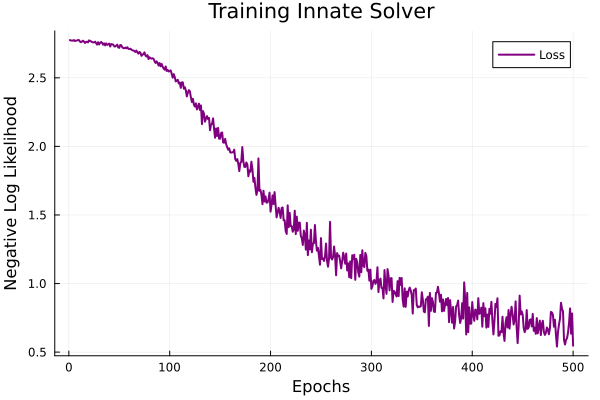

In [22]:
TRAIN_MODEL = false

const PARAMS_FILE = "innate_solver_params.jld2"

const NUM_EPOCHS = 500
const EPOCH_SIZE = 50
const LEARNING_RATE = 0.001

if TRAIN_MODEL
    losses = train_innate_solver()
    display(plot(losses, 
        label="Loss", 
        title="Training Innate Solver", 
        xlabel="Epochs", 
        ylabel="Negative Log Likelihood",
        linewidth=2, color=:purple
    ))
elseif isfile(PARAMS_FILE)
    losses = load_nn_params()
    println("Skipped training, loaded saved parameters.")
    display(plot(losses, 
        label="Loss", 
        title="Training Innate Solver", 
        xlabel="Epochs", 
        ylabel="Negative Log Likelihood",
        linewidth=2, color=:purple
    ))
else
    error("No saved model found. Set TRAIN=true to train the model first.")
end

# Results Visualization

In [23]:
function all_language_types()
    languages = NamedTuple[]
    for hd in [false, true]
        for sd in [false, true]
            for ao in [false, true]
                for wh in [false, true]
                    push!(languages, (hd=hd, sd=sd, ao=ao, wh=wh))
                end
            end
        end
    end
    return languages
end

all_language_types (generic function with 1 method)

In [24]:
function predict_nn(input_vec::Vector{Float64}, params)
    hidden = σ(params.W1 * input_vec + params.b1)
    output = params.W2 * hidden + params.b2
    probs = sigmoid(output)

    return probs
end

predict_nn (generic function with 1 method)

In [25]:
@gen function nn_proposal(input_vec::Vector{Float64}, nn_params::NamedTuple)
    nn_probs = predict_nn(input_vec, nn_params)
    
    hd = @trace(bernoulli(nn_probs[1]), :head_direction)
    sd = @trace(bernoulli(nn_probs[2]), :subject_drop)
    ao = @trace(bernoulli(nn_probs[3]), :adj_order)
    wh = @trace(bernoulli(nn_probs[4]), :wh_fronting)
    
    return (hd=hd, sd=sd, ao=ao, wh=wh)
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, NamedTuple], false, Union{Nothing, Some{Any}}[nothing, nothing], var"##nn_proposal#296", Bool[0, 0], false)

In [26]:
function run_smc(
    trace,
    n_sentences::Int;
    n_particles::Int = 100,
    ess_threshold::Float64 = 0.5,
    use_nn_init::Bool = false,
    input_vec::Union{Vector{Float64}, Nothing} = nothing
)
    # Get observations for first sentence
    init_obs = make_token_obs_upto(trace, 1)

    nn_params = (
        W1 = get_param(innate_solver, :W1),
        b1 = get_param(innate_solver, :b1),
        W2 = get_param(innate_solver, :W2),
        b2 = get_param(innate_solver, :b2)
    )
    
    # Initialize particle filter
    if use_nn_init && input_vec !== nothing
        # Use NN as proposal for initial particles
        state = Gen.initialize_particle_filter(
            corpus_model,
            (1,),
            init_obs,
            nn_proposal,
            (input_vec, nn_params),
            n_particles
        )
    else
        # Use default (prior) proposal
        state = Gen.initialize_particle_filter(
            corpus_model,
            (1,),
            init_obs,
            n_particles
        )
    end
    
    history = Dict(
        :map_estimate => NamedTuple[],
        :posterior_probs => Vector{Float64}[], 
        :ess => Float64[],
        :resampled => Bool[]
    )
    
    # Record initial state
    record_state!(history, state)
    
    # Process remaining sentences
    for t in 2:n_sentences
        new_obs = make_token_obs_for_sentence(trace, t)
        
        Gen.particle_filter_step!(
            state,
            (t,),                           
            (UnknownChange(),),             
            new_obs                     
        )
        
        # Resample
        did_resample = Gen.maybe_resample!(
            state, 
            ess_threshold=ess_threshold * n_particles
        )
        push!(history[:resampled], did_resample)
        
        record_state!(history, state)
    end
    
    return history
end

run_smc (generic function with 1 method)

In [27]:
function record_state!(history, state::Gen.ParticleFilterState)
    log_weights = Gen.get_log_weights(state)
    
    log_Z = Gen.logsumexp(log_weights)
    weights = exp.(log_weights .- log_Z)

    ess = Gen.effective_sample_size(log_weights)
    push!(history[:ess], ess)

    traces = Gen.get_traces(state)
    
    all_thetas = all_language_types()
    theta_probs = zeros(16)
    
    for (tr, w) in zip(traces, weights)
        theta = (
            hd = tr[:head_direction],
            sd = tr[:subject_drop],
            ao = tr[:adj_order],
            wh = tr[:wh_fronting]
        )
        idx = findfirst(t -> t == theta, all_thetas)
        theta_probs[idx] += w
    end
    
    push!(history[:posterior_probs], theta_probs)
    
    # MAP estimate
    map_idx = argmax(theta_probs)
    push!(history[:map_estimate], all_thetas[map_idx])
end

record_state! (generic function with 1 method)

In [28]:
function compute_smc_convergence(history, target::NamedTuple)
    map_estimates = history[:map_estimate]
    n = length(map_estimates)
    
    # Check correctness at each step
    correct = [est == target for est in map_estimates]
    
    # First step where MAP = target
    first_correct = findfirst(correct)
    conv_step = first_correct === nothing ? n : first_correct
    
    # Hamming distance over time
    hamming = [
        4 - sum([
            map_estimates[i].hd == target.hd,
            map_estimates[i].sd == target.sd,
            map_estimates[i].ao == target.ao,
            map_estimates[i].wh == target.wh
        ]) for i in 1:n
    ]
    
    # Posterior probability of true theta over time
    all_thetas = all_language_types()
    target_idx = findfirst(t -> t == target, all_thetas)
    target_prob_history = [probs[target_idx] for probs in history[:posterior_probs]]
    
    # Entropy over time
    entropy_history = [
        -sum(p > 0 ? p * log(p) : 0.0 for p in probs)
        for probs in history[:posterior_probs]
    ]
    
    return (
        convergence_step = conv_step,
        final_correct = correct[end],
        stayed_converged = first_correct !== nothing && all(correct[first_correct:end]),
        target_prob_history = target_prob_history,
        entropy_history = entropy_history,
        ess_history = history[:ess]
    )
end

compute_smc_convergence (generic function with 1 method)

In [29]:
function run_trial_smc(
    theta::NamedTuple; 
    n_sentences::Int = NUM_SENTS_TRAIN,
    n_particles::Int = 100
)
    trace, _ = generate(corpus_model, (n_sentences,), make_constraints(theta))
    sentences = get_retval(trace)
    input_vec = encode_corpus(sentences)

    naive_history = run_smc(trace, n_sentences; n_particles=n_particles, use_nn_init=false)
    guided_history = run_smc(trace, n_sentences; n_particles=n_particles, use_nn_init=true, input_vec=input_vec)
    
    naive_metrics = compute_smc_metrics(naive_history, theta, n_sentences)
    guided_metrics = compute_smc_metrics(guided_history, theta, n_sentences)

    nn_params = (
        W1 = get_param(innate_solver, :W1),
        b1 = get_param(innate_solver, :b1),
        W2 = get_param(innate_solver, :W2),
        b2 = get_param(innate_solver, :b2)
    )
    nn_probs = predict_nn(input_vec, nn_params)
    nn_preds = (
        hd = nn_probs[1] > 0.5,
        sd = nn_probs[2] > 0.5,
        ao = nn_probs[3] > 0.5,
        wh = nn_probs[4] > 0.5,
    )
    
    nn_correct = (nn_preds.hd == theta.hd && nn_preds.sd == theta.sd &&
                  nn_preds.ao == theta.ao && nn_preds.wh == theta.wh)
    
    return (
        naive_metrics = naive_metrics,
        guided_metrics = guided_metrics,
        nn_correct = nn_correct,
        nn_probs = nn_probs,
        nn_preds = nn_preds,
        theta = theta,
        sentences_ids = sentences
    )
end

run_trial_smc (generic function with 1 method)

In [30]:
function compute_smc_metrics(history, target::NamedTuple, n_sentences::Int)
    map_estimates = history[:map_estimate]
    
    # Did it ever converge?
    correct = [est == target for est in map_estimates]
    ever_converged = any(correct)
    
    # First convergence (or nothing)
    first_correct = findfirst(correct)
    
    # Final accuracy
    final_correct = correct[end]
    
    # Posterior probability of target over time
    all_thetas = all_language_types()
    target_idx = findfirst(t -> t == target, all_thetas)
    target_prob_history = [probs[target_idx] for probs in history[:posterior_probs]]
    
    # Area under the learning curve (higher = faster learning)
    auc = sum(target_prob_history) / n_sentences
    
    # Sentences to reach 50% posterior on correct grammar
    idx_50 = findfirst(p -> p >= 0.5, target_prob_history)
    sentences_to_50 = idx_50 === nothing ? Inf : idx_50
    
    # Sentences to reach 90% posterior
    idx_90 = findfirst(p -> p >= 0.9, target_prob_history)
    sentences_to_90 = idx_90 === nothing ? Inf : idx_90
    
    return (
        ever_converged = ever_converged,
        first_correct = first_correct,
        final_correct = final_correct,
        final_target_prob = target_prob_history[end],
        target_prob_history = target_prob_history,
        auc = auc,
        sentences_to_50 = sentences_to_50,
        sentences_to_90 = sentences_to_90
    )
end

compute_smc_metrics (generic function with 1 method)

In [31]:
function compute_nn_metrics(trials)
    # Per-parameter accuracy
    hd_acc = mean([t.nn_preds.hd == t.theta.hd for t in trials])
    sd_acc = mean([t.nn_preds.sd == t.theta.sd for t in trials])
    ao_acc = mean([t.nn_preds.ao == t.theta.ao for t in trials])
    wh_acc = mean([t.nn_preds.wh == t.theta.wh for t in trials])
    
    # Exact match
    exact_match = mean([t.nn_correct for t in trials])
    
    # Hamming accuracy
    hamming_acc = mean([
        sum([
            t.nn_preds.hd == t.theta.hd,
            t.nn_preds.sd == t.theta.sd,
            t.nn_preds.ao == t.theta.ao,
            t.nn_preds.wh == t.theta.wh
        ]) / 4.0
        for t in trials
    ])
    
    return (
        per_param = (hd=hd_acc, sd=sd_acc, ao=ao_acc, wh=wh_acc),
        mean_param = mean([hd_acc, sd_acc, ao_acc, wh_acc]),
        exact_match = exact_match,
        hamming = hamming_acc
    )
end

compute_nn_metrics (generic function with 1 method)

In [32]:
function create_smc_summary_dashboard(all_trials)
    n_trials = length(all_trials)
    n_sentences = length(all_trials[1].naive_metrics.target_prob_history)
    
    # Aggregate metrics
    naive_converged = mean([t.naive_metrics.ever_converged for t in all_trials])
    guided_converged = mean([t.guided_metrics.ever_converged for t in all_trials])
    
    naive_final_prob = mean([t.naive_metrics.final_target_prob for t in all_trials])
    guided_final_prob = mean([t.guided_metrics.final_target_prob for t in all_trials])
    
    naive_auc = mean([t.naive_metrics.auc for t in all_trials])
    guided_auc = mean([t.guided_metrics.auc for t in all_trials])
    
    # Learning curves
    naive_curves = [t.naive_metrics.target_prob_history for t in all_trials]
    guided_curves = [t.guided_metrics.target_prob_history for t in all_trials]
    avg_naive = [mean([c[i] for c in naive_curves]) for i in 1:n_sentences]
    avg_guided = [mean([c[i] for c in guided_curves]) for i in 1:n_sentences]
    
    # Survival curves: fraction that reached 50% by each step
    function survival_curve(trials, threshold=0.5)
        n_sent = length(trials[1].naive_metrics.target_prob_history)
        [mean([any(t.naive_metrics.target_prob_history[1:i] .>= threshold) for t in trials]) for i in 1:n_sent]
    end
    naive_survival = [mean([t.naive_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    guided_survival = [mean([t.guided_metrics.sentences_to_50 <= i for t in all_trials]) for i in 1:n_sentences]
    
    # NN metrics
    nn_metrics = compute_nn_metrics(all_trials)
    
    # Create dashboard
    p = plot(layout=@layout([a b; c d]), size=(1200, 800),
             plot_title="Universal Grammar Learning: SMC Summary")
    
    # Panel 1: Average learning curves
    plot!(p[1], 1:n_sentences, avg_naive, label="Naive SMC", 
          linewidth=3, color=:indianred, ribbon=std.([[c[i] for c in naive_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p[1], 1:n_sentences, avg_guided, label="NN-Guided SMC", 
          linewidth=3, color=:steelblue, ribbon=std.([[c[i] for c in guided_curves] for i in 1:n_sentences])/sqrt(n_trials), fillalpha=0.2)
    plot!(p[1], xlabel="Sentences observed", ylabel="P(correct grammar)",
          title="Learning Curves (± SE)", legend=:bottomright)
    
    # Panel 2: Survival curves (fraction reached 50% confidence)
    plot!(p[2], 1:n_sentences, naive_survival, label="Naive SMC",
          linewidth=3, color=:indianred)
    plot!(p[2], 1:n_sentences, guided_survival, label="NN-Guided SMC",
          linewidth=3, color=:steelblue)
    plot!(p[2], xlabel="Sentences observed", ylabel="Fraction reached 50% confidence",
          title="Cumulative Convergence", legend=:bottomright)
    hline!(p[2], [0.5, 1.0], linestyle=:dash, color=:gray, alpha=0.5, label="")
    
    # Panel 3: NN Per-parameter accuracy
    param_labels = ["Head\nDir", "Subj\nDrop", "Adj\nOrder", "Wh-\nFront"]
    param_accs = [nn_metrics.per_param.hd, nn_metrics.per_param.sd, 
                  nn_metrics.per_param.ao, nn_metrics.per_param.wh]
    bar!(p[3], param_labels, param_accs, title="NN Per-Parameter Accuracy",
         ylabel="Accuracy", legend=false, color=:steelblue, fillalpha=0.7, ylim=(0,1.1))
    hline!(p[3], [0.5], linestyle=:dash, color=:gray, linewidth=2)
    
    # Panel 4: Summary statistics
    plot!(p[4], axis=false, grid=false, ticks=false, xlim=(0,1), ylim=(0,1))
    
    annotate!(p[4], 0.5, 0.95, text("KEY METRICS", :center, 14))
    annotate!(p[4], 0.5, 0.88, text("─"^50, :center, 10))
    
    annotate!(p[4], 0.3, 0.78, text("Naive SMC", :center, 12))
    annotate!(p[4], 0.7, 0.78, text("NN-Guided SMC", :center, 12))
    
    annotate!(p[4], 0.3, 0.68, text("Final P(correct): $(round(naive_final_prob*100, digits=1))%", :center, 10))
    annotate!(p[4], 0.7, 0.68, text("Final P(correct): $(round(guided_final_prob*100, digits=1))%", :center, 10))
    
    annotate!(p[4], 0.3, 0.58, text("Ever converged: $(round(naive_converged*100, digits=1))%", :center, 10))
    annotate!(p[4], 0.7, 0.58, text("Ever converged: $(round(guided_converged*100, digits=1))%", :center, 10))
    
    annotate!(p[4], 0.3, 0.48, text("AUC: $(round(naive_auc, digits=3))", :center, 10))
    annotate!(p[4], 0.7, 0.48, text("AUC: $(round(guided_auc, digits=3))", :center, 10))
    
    annotate!(p[4], 0.5, 0.35, text("─"^50, :center, 10))
    
    # Relative improvement
    auc_improvement = (guided_auc - naive_auc) / naive_auc * 100
    prob_improvement = (guided_final_prob - naive_final_prob) / max(naive_final_prob, 0.01) * 100
    
    annotate!(p[4], 0.5, 0.25, text("AUC Improvement: +$(round(auc_improvement, digits=1))%", :center, 11))
    annotate!(p[4], 0.5, 0.15, text("Final Prob Improvement: +$(round(prob_improvement, digits=1))%", :center, 11))
    annotate!(p[4], 0.5, 0.05, text("NN Exact Match: $(round(nn_metrics.exact_match*100, digits=1))% | Hamming: $(round(nn_metrics.hamming*100, digits=1))%", :center, 10))
    
    return p
end

create_smc_summary_dashboard (generic function with 1 method)

In [33]:
all_trials = []
for theta in all_language_types()
    for i in 1:5
        println("Iteration $i for theta=$theta")
        push!(all_trials, run_trial_smc(theta; n_sentences=30, n_particles=200))
    end
    GC.gc()
end

Iteration 1 for theta=(hd = false, sd = false, ao = false, wh = false)
Iteration 2 for theta=(hd = false, sd = false, ao = false, wh = false)
Iteration 3 for theta=(hd = false, sd = false, ao = false, wh = false)
Iteration 4 for theta=(hd = false, sd = false, ao = false, wh = false)
Iteration 5 for theta=(hd = false, sd = false, ao = false, wh = false)
Iteration 1 for theta=(hd = false, sd = false, ao = false, wh = true)
Iteration 2 for theta=(hd = false, sd = false, ao = false, wh = true)
Iteration 3 for theta=(hd = false, sd = false, ao = false, wh = true)
Iteration 4 for theta=(hd = false, sd = false, ao = false, wh = true)
Iteration 5 for theta=(hd = false, sd = false, ao = false, wh = true)
Iteration 1 for theta=(hd = false, sd = false, ao = true, wh = false)
Iteration 2 for theta=(hd = false, sd = false, ao = true, wh = false)
Iteration 3 for theta=(hd = false, sd = false, ao = true, wh = false)
Iteration 4 for theta=(hd = false, sd = false, ao = true, wh = false)
Iteration 5 for

In [45]:
# @save "smc_results_backup.jld2" all_trials

In [46]:
# @load "smc_results_backup.jld2" all_trials

## Other useful analytics

In [41]:
# === 1. Per-Language Heatmap: Which languages are harder to learn? ===
function create_language_difficulty_heatmap(all_trials)
    languages = all_language_types()
    n_langs = length(languages)
    
    # Group trials by language
    trials_by_lang = Dict()
    for t in all_trials
        key = (t.theta.hd, t.theta.sd, t.theta.ao, t.theta.wh)
        if !haskey(trials_by_lang, key)
            trials_by_lang[key] = []
        end
        push!(trials_by_lang[key], t)
    end
    
    # Compute metrics per language
    lang_labels = String[]
    naive_probs = Float64[]
    guided_probs = Float64[]
    nn_acc = Float64[]
    
    for theta in languages
        key = (theta.hd, theta.sd, theta.ao, theta.wh)
        trials = trials_by_lang[key]
        
        label = string(
            theta.hd ? "VO" : "OV", "-",
            theta.sd ? "drop" : "keep", "-",
            theta.ao ? "AN" : "NA", "-",
            theta.wh ? "front" : "situ"
        )
        push!(lang_labels, label)
        push!(naive_probs, mean([t.naive_metrics.final_target_prob for t in trials]))
        push!(guided_probs, mean([t.guided_metrics.final_target_prob for t in trials]))
        push!(nn_acc, mean([t.nn_correct for t in trials]))
    end
    
    # Sort by guided performance
    order = sortperm(guided_probs, rev=true)
    
    p = groupedbar(
        lang_labels[order],
        hcat(naive_probs[order], guided_probs[order]),
        label=["Naive SMC" "NN-Guided SMC"],
        title="Final P(correct) by Language Type",
        ylabel="P(correct grammar)",
        xrotation=45,
        color=[:indianred :steelblue],
        fillalpha=0.7,
        size=(900, 500),
        legend=:topright
    )
    hline!([0.5], linestyle=:dash, color=:gray, label="")
    
    return p
end

create_language_difficulty_heatmap (generic function with 1 method)

In [42]:
# === 2. Learning Speed: Sentences needed to reach 90% confidence ===
function create_convergence_speed_plot(all_trials)
    languages = all_language_types()
    
    trials_by_lang = Dict()
    for t in all_trials
        key = (t.theta.hd, t.theta.sd, t.theta.ao, t.theta.wh)
        if !haskey(trials_by_lang, key)
            trials_by_lang[key] = []
        end
        push!(trials_by_lang[key], t)
    end
    
    lang_labels = String[]
    naive_speed = Float64[]
    guided_speed = Float64[]
    
    for theta in languages
        key = (theta.hd, theta.sd, theta.ao, theta.wh)
        trials = trials_by_lang[key]
        
        label = string(
            theta.hd ? "VO" : "OV", "-",
            theta.sd ? "D" : "K", "-",
            theta.ao ? "AN" : "NA", "-",
            theta.wh ? "F" : "S"
        )
        push!(lang_labels, label)
        
        n_sent = length(trials[1].guided_metrics.target_prob_history)
        push!(naive_speed, mean([min(t.naive_metrics.sentences_to_90, n_sent) for t in trials]))
        push!(guided_speed, mean([min(t.guided_metrics.sentences_to_90, n_sent) for t in trials]))
    end
    
    order = sortperm(guided_speed)
    
    # Use grouped bar without subplots
    p = groupedbar(
        lang_labels[order],
        hcat(naive_speed[order], guided_speed[order]),
        label=["Naive SMC" "NN-Guided SMC"],
        title="Sentences to Reach 90% Posterior on Correct Grammar",
        ylabel="Sentences needed (30 = never reached)",
        xrotation=45,
        color=[:indianred :steelblue],
        fillalpha=0.7,
        size=(900, 500),
        legend=:topleft
    )
    
    return p
end

create_convergence_speed_plot (generic function with 1 method)

In [40]:
# === 3. Parameter-wise Analysis: Which parameters are hardest? ===

function create_parameter_difficulty_analysis(all_trials)
    params = [:hd, :sd, :ao, :wh]
    param_names = ["Head Direction", "Subject Drop", "Adjective Order", "Wh-Fronting"]
    
    p = plot(layout=(2, 2), size=(1000, 800), 
             plot_title="Learning Difficulty by Parameter Value")
    
    for (idx, (param, name)) in enumerate(zip(params, param_names))
        true_trials = [t for t in all_trials if getfield(t.theta, param) == true]
        false_trials = [t for t in all_trials if getfield(t.theta, param) == false]
        
        true_guided = mean([t.guided_metrics.final_target_prob for t in true_trials])
        false_guided = mean([t.guided_metrics.final_target_prob for t in false_trials])
        true_naive = mean([t.naive_metrics.final_target_prob for t in true_trials])
        false_naive = mean([t.naive_metrics.final_target_prob for t in false_trials])
        
        # Use regular bar plot with manual positioning
        x_pos = [1, 2, 4, 5]  # Grouped positions
        heights = [false_naive, false_guided, true_naive, true_guided]
        colors = [:indianred, :steelblue, :indianred, :steelblue]
        
        bar!(p[idx], x_pos, heights,
            color=colors,
            fillalpha=0.7,
            title=name,
            ylabel="P(correct)",
            xticks=([1.5, 4.5], ["$param=false", "$param=true"]),
            ylim=(0, 1),
            legend=false
        )
        hline!(p[idx], [0.5], linestyle=:dash, color=:gray, label="")
    end
    
    # Add a manual legend to first subplot
    plot!(p[1], [], [], color=:indianred, fillalpha=0.7, label="Naive", seriestype=:bar)
    plot!(p[1], [], [], color=:steelblue, fillalpha=0.7, label="Guided", seriestype=:bar)
    
    return p
end

create_parameter_difficulty_analysis (generic function with 1 method)

In [37]:
# 4. NN Calibration: When NN is confident, is it right? ===

function create_nn_calibration_plot(all_trials)
    # Bin trials by NN confidence and check accuracy
    max_probs = Float64[]
    correct = Bool[]
    
    for t in all_trials
        # Get NN's confidence (max probability across parameters)
        nn_probs = [
            t.theta.hd ? t.nn_probs[1] : 1 - t.nn_probs[1],
            t.theta.sd ? t.nn_probs[2] : 1 - t.nn_probs[2],
            t.theta.ao ? t.nn_probs[3] : 1 - t.nn_probs[3],
            t.theta.wh ? t.nn_probs[4] : 1 - t.nn_probs[4]
        ]
        push!(max_probs, mean(nn_probs))  # Average confidence
        push!(correct, t.nn_correct)
    end
    
    # Bin by confidence
    bins = 0.5:0.1:1.0
    bin_acc = Float64[]
    bin_counts = Int[]
    bin_centers = Float64[]
    
    for i in 1:(length(bins)-1)
        mask = (max_probs .>= bins[i]) .& (max_probs .< bins[i+1])
        if sum(mask) > 0
            push!(bin_acc, mean(correct[mask]))
            push!(bin_counts, sum(mask))
            push!(bin_centers, (bins[i] + bins[i+1]) / 2)
        end
    end
    
    p = plot(size=(600, 500))
    
    # Perfect calibration line
    plot!(p, [0.5, 1.0], [0.5, 1.0], linestyle=:dash, color=:gray, 
          label="Perfect calibration", linewidth=2)
    
    # Actual calibration
    scatter!(p, bin_centers, bin_acc, 
             markersize=sqrt.(bin_counts) .* 2,
             color=:steelblue,
             label="NN calibration",
             alpha=0.7)
    
    plot!(p, bin_centers, bin_acc, color=:steelblue, linewidth=2, label="")
    
    plot!(p, 
          xlabel="NN Confidence", 
          ylabel="Actual Accuracy",
          title="NN Calibration (marker size = sample count)",
          xlim=(0.45, 1.05),
          ylim=(0.45, 1.05),
          legend=:bottomright
    )
    
    return p
end

create_nn_calibration_plot (generic function with 1 method)

In [38]:
# Typological Comparison: Natural vs Rare Language Types

function create_typological_comparison(all_trials)
    natural_patterns = [
        (hd=true, sd=false, ao=true, wh=true),   # English
        (hd=false, sd=true, ao=false, wh=false), # Japanese
        (hd=true, sd=true, ao=false, wh=true),   # Spanish
        (hd=false, sd=false, ao=false, wh=false), # German-ish
    ]
    
    natural_trials = [t for t in all_trials if t.theta in natural_patterns]
    rare_trials = [t for t in all_trials if !(t.theta in natural_patterns)]
    
    p = plot(layout=(1, 2), size=(1000, 400),
             plot_title="Natural vs Typologically Rare Languages")
    
    # Learning curves
    n_sent = length(all_trials[1].guided_metrics.target_prob_history)
    
    natural_curves = [t.guided_metrics.target_prob_history for t in natural_trials]
    rare_curves = [t.guided_metrics.target_prob_history for t in rare_trials]
    
    avg_natural = [mean([c[i] for c in natural_curves]) for i in 1:n_sent]
    avg_rare = [mean([c[i] for c in rare_curves]) for i in 1:n_sent]
    
    plot!(p[1], 1:n_sent, avg_natural, label="Natural types (n=$(length(natural_trials)))", 
          linewidth=3, color=:forestgreen)
    plot!(p[1], 1:n_sent, avg_rare, label="Rare types (n=$(length(rare_trials)))", 
          linewidth=3, color=:darkorange)
    plot!(p[1], xlabel="Sentences", ylabel="P(correct)", title="Learning Curves",
          legend=:bottomright)
    
    # Final accuracy comparison
    natural_acc = mean([t.guided_metrics.final_target_prob for t in natural_trials])
    rare_acc = mean([t.guided_metrics.final_target_prob for t in rare_trials])
    
    bar!(p[2], ["Natural\nLanguages", "Rare\nLanguages"], 
         [natural_acc, rare_acc],
         color=[:forestgreen, :darkorange],
         fillalpha=0.7,
         title="Final Accuracy",
         ylabel="P(correct)",
         legend=false,
         ylim=(0, 1)
    )
    
    return p
end

create_typological_comparison (generic function with 1 method)

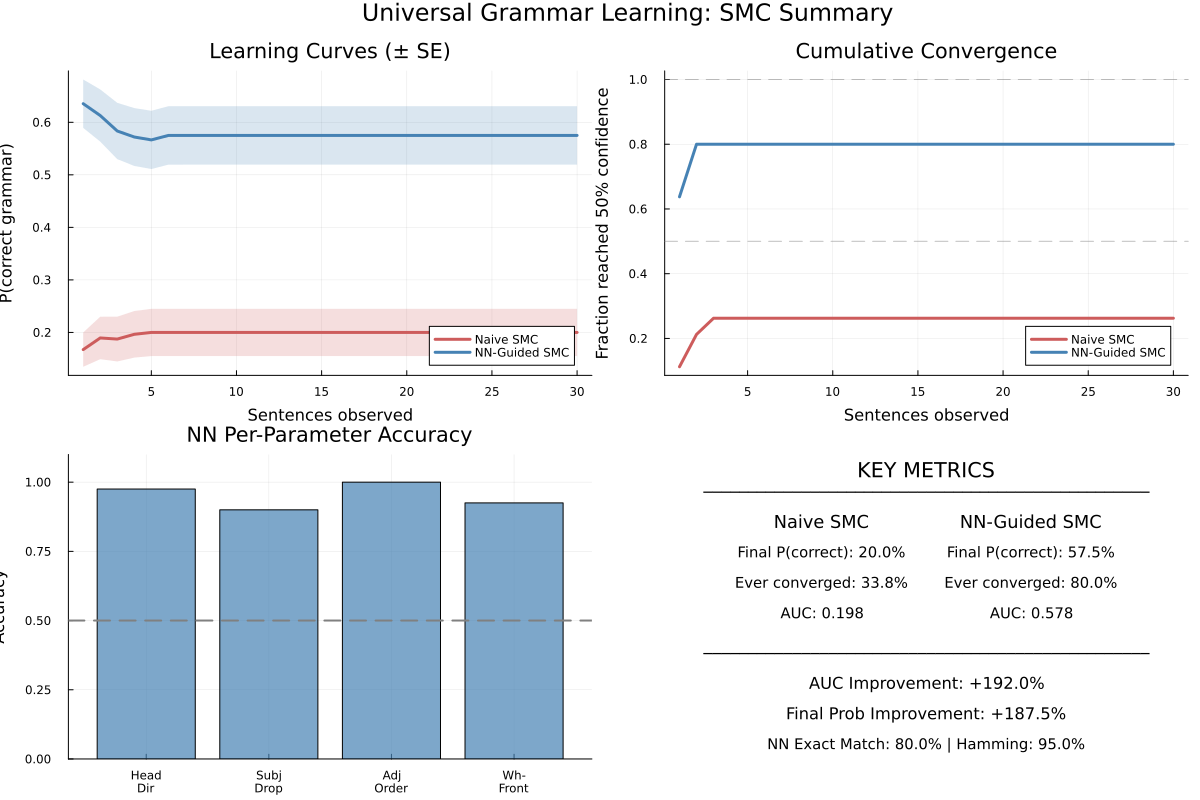

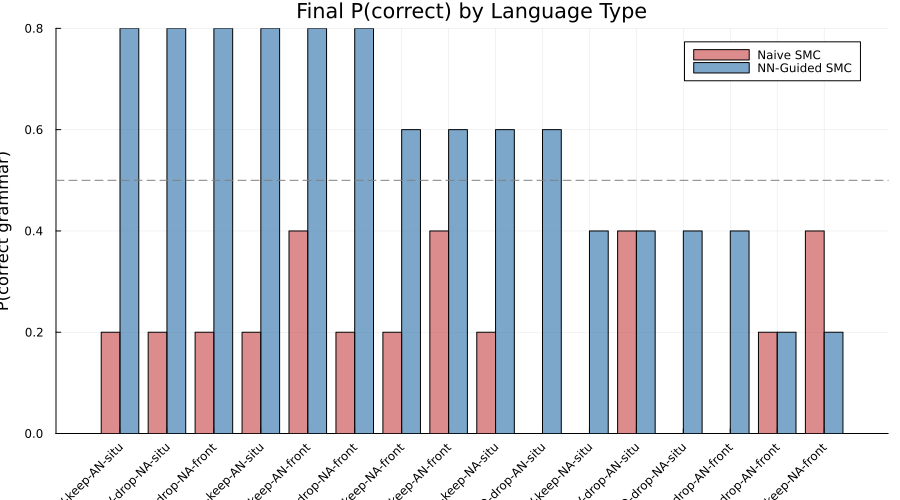

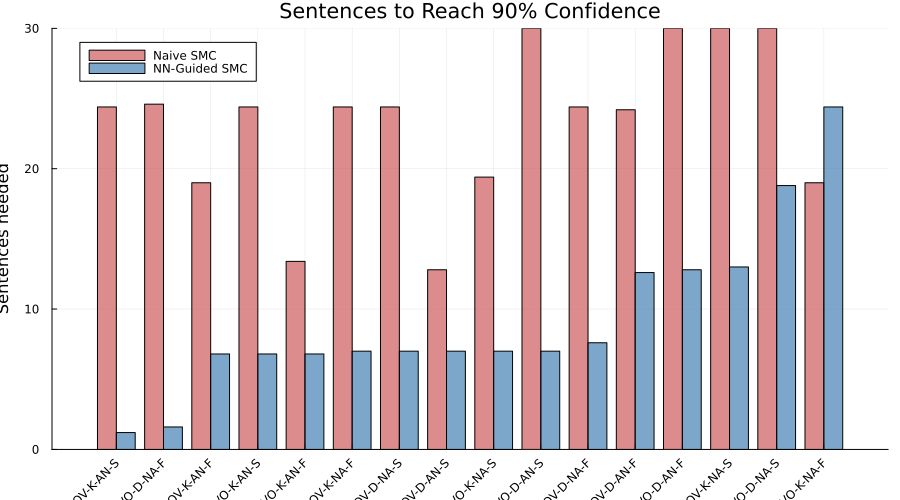

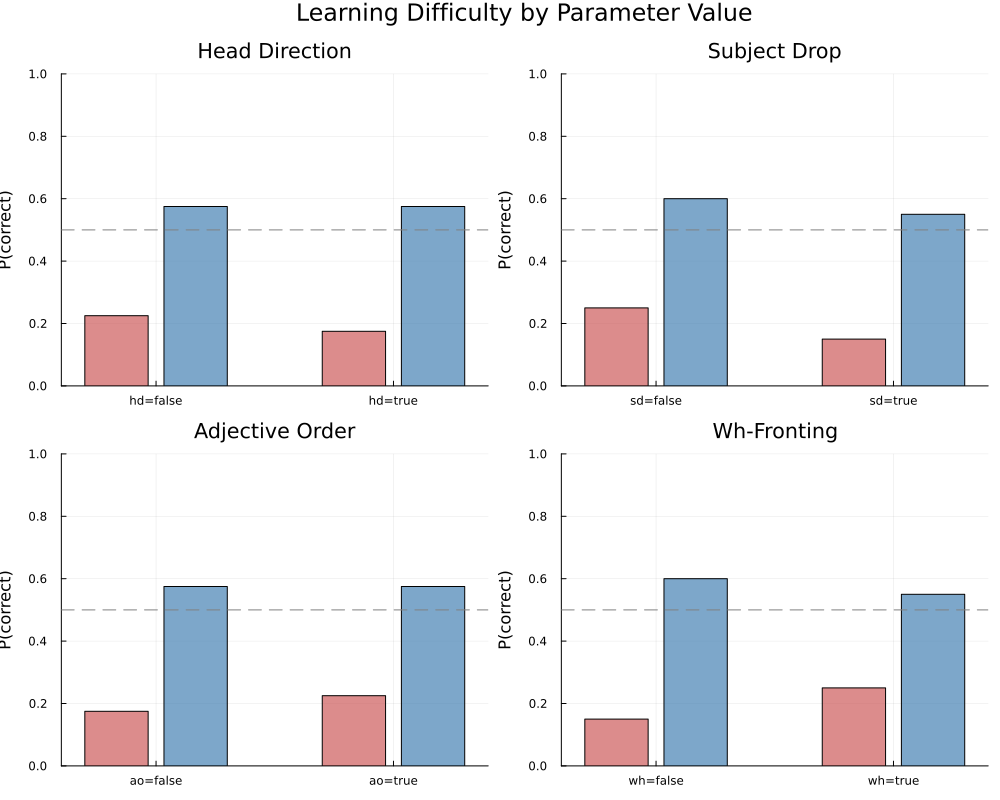

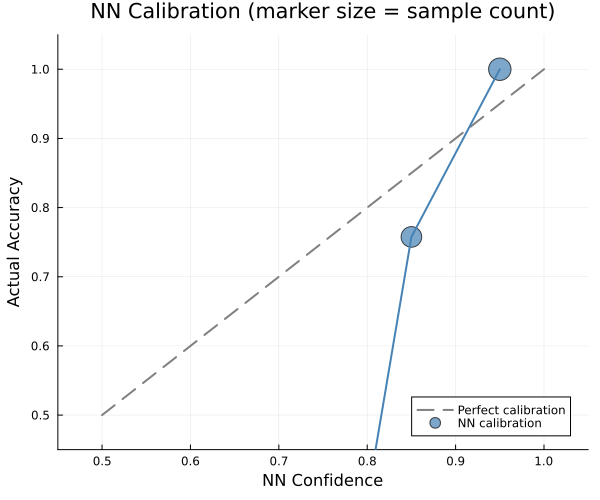

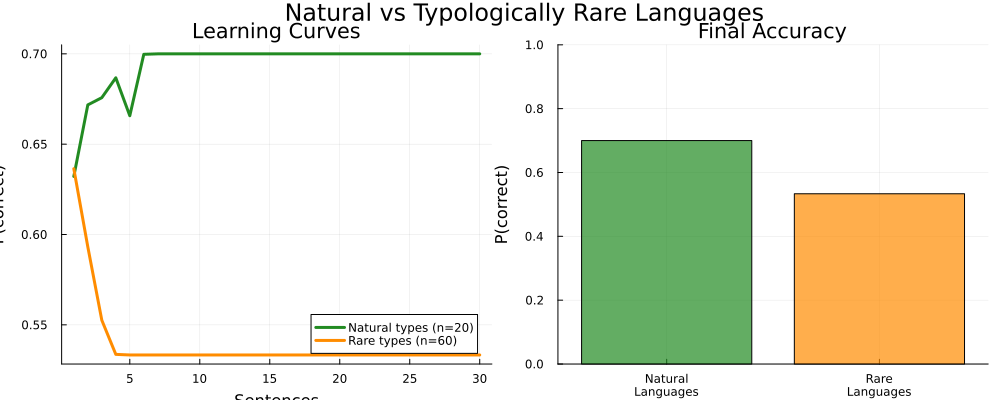

Per-param accuracy: (hd = 0.975, sd = 0.9, ao = 1.0, wh = 0.925)
Exact match: 0.8


In [43]:
# Main dashboard
p1 = create_smc_summary_dashboard(all_trials)
display(p1)

# Additional visualizations
p2 = create_language_difficulty_heatmap(all_trials)
display(p2)

p3 = create_convergence_speed_plot(all_trials)
display(p3)

p4 = create_parameter_difficulty_analysis(all_trials)
display(p4)

p5 = create_nn_calibration_plot(all_trials)
display(p5)

p6 = create_typological_comparison(all_trials)
display(p6)

# Print metrics
nn_metrics = compute_nn_metrics(all_trials)
println("Per-param accuracy: ", nn_metrics.per_param)
println("Exact match: ", nn_metrics.exact_match)